In [16]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 2.7 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.5 MB 3.3 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 4.1 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 4.7 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 5.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 5.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.6 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --------

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("household_power_consumption.txt", sep=";")

df.replace("?", np.nan, inplace=True)

df["Global_active_power"] = pd.to_numeric(df["Global_active_power"])

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

df = df.set_index("datetime")

df = df.dropna()

C:\Users\anush\AppData\Local\Temp\ipykernel_816\3620562067.py:4: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.txt", sep=";")
C:\Users\anush\AppData\Local\Temp\ipykernel_816\3620562067.py:10: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


In [22]:
power = df["Global_active_power"]

daily_power = power.resample("D").sum()

In [23]:
last_30_days = daily_power[-30:]

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    last_30_days,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

model_fit = model.fit()

In [25]:
forecast = model_fit.forecast(steps=30)

print(forecast)

2010-11-27    1854.202023
2010-11-28    1544.342678
2010-11-29    1612.577027
2010-11-30    1425.726709
2010-12-01    1494.270387
2010-12-02    1525.608558
2010-12-03    1441.450747
2010-12-04    1907.849601
2010-12-05    1128.676744
2010-12-06    1711.674023
2010-12-07    1391.729974
2010-12-08    1532.457098
2010-12-09    1373.142271
2010-12-10    1356.844498
2010-12-11    1775.003507
2010-12-12    1221.549215
2010-12-13    1556.968756
2010-12-14    1301.036786
2010-12-15    1407.046928
2010-12-16    1339.427595
2010-12-17    1290.492204
2010-12-18    1731.852402
2010-12-19    1069.837661
2010-12-20    1524.330928
2010-12-21    1237.612035
2010-12-22    1360.319480
2010-12-23    1248.598750
2010-12-24    1215.360581
2010-12-25    1645.562053
2010-12-26    1035.759992
Freq: D, Name: predicted_mean, dtype: float64


In [26]:
next_month_consumption = forecast.sum()

print("Predicted next month energy:", next_month_consumption)

Predicted next month energy: 43261.31121170015


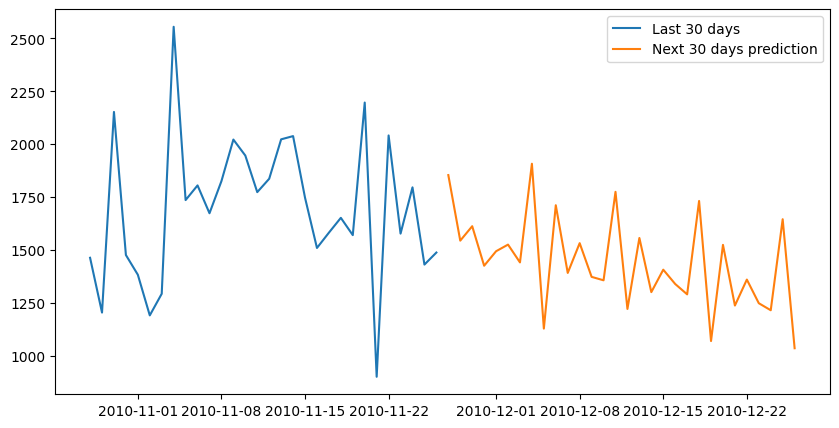

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(last_30_days, label="Last 30 days")

plt.plot(forecast, label="Next 30 days prediction")

plt.legend()

plt.show()

In [28]:
import joblib

joblib.dump(model_fit, "models/energy_sarima_model.pkl")

['models/energy_sarima_model.pkl']

['models/scaler.save']